# Final results — text-aware DTD

Produces every number and figure for the presentation, on the canonical protocol
(**DocTamperV1-TrainingSet → DocTamperV1-TestingSet**, seed 42, 800/200/200).

Arms: `checkpoint` (no training) · `none` · `easyocr` · `tesseract`.
Adds two analyses missing from earlier runs: the **no-train control** and **threshold-optimal F1**.
Outputs tables + figures to Drive.

In [1]:
# --- CONFIG: read shared checkpoints, write to your own folder ---
from pathlib import Path

CONFIG = {
    'PROJECT_REPO_URL': 'https://github.com/SamiraAbedini/HLCV-Project.git',
    'PROJECT_BRANCH': 'main',
    'PROJECT_DIR': '/content/HLCV-Project',
    'DOCTAMPER_DIR': '/content/DocTamper',

    # READ (shared folder shortcut) / WRITE (yours -- never clobbers your teammate)
    'CHECKPOINT_DIR': '/content/drive/MyDrive/HLCV/checkpoints',
    'OUT_ROOT':       '/content/drive/MyDrive/HLCV_samira/final_seed42',
    'MANIFEST_DIR':   '/content/drive/MyDrive/HLCV_samira/manifests/train800_val200_test200_seed42',

    # Data: the ~2 GB zip is cached on Drive; the extracted LMDBs live on temp disk.
    'DRIVE_ZIP': '/content/drive/MyDrive/HLCV_samira/data/doctamper.zip',
    'CACHE_ZIP_TO_DRIVE': True,
    'KAGGLE_DATASET': 'dinmkeljiame/doctamper',
    'DATA_ROOT': '/content/doctamper_train_test',

    'SEED': 42,
    'TRAIN_SOURCE': 'DocTamperV1-TrainingSet',
    'TEST_SOURCE': 'DocTamperV1-TestingSet',
    'TRAIN_SIZE': 800, 'VAL_SIZE': 200, 'TEST_SIZE': 200,

    'BATCH_SIZE': 2, 'TRAIN_STEPS': 400, 'WEIGHT_DECAY': 1e-2,
    'JPEG_QUALITY': 75, 'EVAL_THRESHOLD': 0.5,
    'OCR_CONFIDENCE_THRESHOLD': 30.0, 'OCR_DILATION': 2, 'OCR_LANGUAGES': ('eng',),
    'TESSERACT_PSM': 6, 'TESSERACT_OEM': 3, 'TESSERACT_CMD': None,
    'INIT_CHECKPOINT': 'dtd_doctamper.pth',
}
BACKENDS = ['none', 'easyocr', 'tesseract']
CONFIG

{'PROJECT_REPO_URL': 'https://github.com/SamiraAbedini/HLCV-Project.git',
 'PROJECT_BRANCH': 'main',
 'PROJECT_DIR': '/content/HLCV-Project',
 'DOCTAMPER_DIR': '/content/DocTamper',
 'CHECKPOINT_DIR': '/content/drive/MyDrive/HLCV/checkpoints',
 'OUT_ROOT': '/content/drive/MyDrive/HLCV_samira/final_seed42',
 'MANIFEST_DIR': '/content/drive/MyDrive/HLCV_samira/manifests/train800_val200_test200_seed42',
 'DRIVE_ZIP': '/content/drive/MyDrive/HLCV_samira/data/doctamper.zip',
 'CACHE_ZIP_TO_DRIVE': True,
 'KAGGLE_DATASET': 'dinmkeljiame/doctamper',
 'DATA_ROOT': '/content/doctamper_train_test',
 'SEED': 42,
 'TRAIN_SOURCE': 'DocTamperV1-TrainingSet',
 'TEST_SOURCE': 'DocTamperV1-TestingSet',
 'TRAIN_SIZE': 800,
 'VAL_SIZE': 200,
 'TEST_SIZE': 200,
 'BATCH_SIZE': 2,
 'TRAIN_STEPS': 400,
 'WEIGHT_DECAY': 0.01,
 'JPEG_QUALITY': 75,
 'EVAL_THRESHOLD': 0.5,
 'OCR_CONFIDENCE_THRESHOLD': 30.0,
 'OCR_DILATION': 2,
 'OCR_LANGUAGES': ('eng',),
 'TESSERACT_PSM': 6,
 'TESSERACT_OEM': 3,
 'TESSERACT_CMD'

In [2]:
# --- Setup: Drive, repos, dependencies ---
from google.colab import drive
drive.mount('/content/drive')

import os, sys, subprocess
assert Path(CONFIG['CHECKPOINT_DIR']).exists(), (
    f"Not found: {CONFIG['CHECKPOINT_DIR']}\n"
    "In Drive, right-click the shared HLCV folder -> 'Add shortcut to Drive' -> My Drive.")

%cd /content
if not Path(CONFIG['PROJECT_DIR']).exists():
    subprocess.run(['git', 'clone', '-q', '-b', CONFIG['PROJECT_BRANCH'],
                    CONFIG['PROJECT_REPO_URL'], CONFIG['PROJECT_DIR']], check=True)
if not Path(CONFIG['DOCTAMPER_DIR']).exists():
    subprocess.run(['git', 'clone', '-q', 'https://github.com/qcf-568/DocTamper.git',
                    CONFIG['DOCTAMPER_DIR']], check=True)

!pip -q install lmdb six albumentations timm==0.4.12 segmentation_models_pytorch==0.2.1 easyocr pytesseract kaggle scikit-learn matplotlib
!pip -q install efficientnet_pytorch==0.7.1
!apt-get -qq install -y tesseract-ocr libjpeg-dev > /dev/null
!pip -q uninstall -y jpegio
!rm -rf /content/jpegio && git clone -q https://github.com/dwgoon/jpegio.git /content/jpegio
%cd /content/jpegio
!pip -q install .
%cd /content/DocTamper/models

sys.path.insert(0, CONFIG['PROJECT_DIR'])
import jpegio
print('jpegio.read:', hasattr(jpegio, 'read'))
print('tesseract  :', subprocess.run(['tesseract', '--version'], capture_output=True, text=True).stdout.splitlines()[0])

Mounted at /content/drive
/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 26.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
segmentation-models-pytorch

In [3]:
# --- Data: cached zip on Drive -> extract to Colab temp disk (Kaggle only as fallback) ---
# The extracted LMDBs are tens of GB and are slow over Drive's FUSE mount, so they live on temp
# disk. Only the ~2 GB zip is cached on Drive, which skips the slow Kaggle download on re-runs.
import getpass, shutil, subprocess

DATA_ROOT = Path(CONFIG['DATA_ROOT']); DATA_ROOT.mkdir(parents=True, exist_ok=True)
DRIVE_ZIP = Path(CONFIG['DRIVE_ZIP'])
need = [DATA_ROOT / CONFIG['TRAIN_SOURCE'] / 'data.mdb', DATA_ROOT / CONFIG['TEST_SOURCE'] / 'data.mdb']

def ensure_kaggle_token():
    """Supports the new token string, a legacy kaggle.json, or env vars."""
    if os.environ.get('KAGGLE_API_TOKEN') or os.environ.get('KAGGLE_KEY'):
        return
    kdir = Path.home() / '.kaggle'; kdir.mkdir(parents=True, exist_ok=True)
    if (kdir / 'kaggle.json').exists() or (kdir / 'access_token').exists():
        return
    token = getpass.getpass('Paste Kaggle API token (hidden): ').strip()
    (kdir / 'access_token').write_text(token)
    (kdir / 'access_token').chmod(0o600)

def get_zip():
    """Return a local path to the dataset zip, preferring the Drive cache."""
    local = Path('/content/doctamper_kaggle/doctamper.zip')
    if local.exists():
        return local
    local.parent.mkdir(parents=True, exist_ok=True)
    if DRIVE_ZIP.exists():
        print('using cached zip from Drive (no Kaggle download)')
        return DRIVE_ZIP                      # unzip reads it straight off Drive
    print('no cached zip -> downloading from Kaggle')
    ensure_kaggle_token()
    subprocess.run(['kaggle', 'datasets', 'download', '-d', CONFIG['KAGGLE_DATASET'],
                    '-p', str(local.parent)], check=True)
    if CONFIG['CACHE_ZIP_TO_DRIVE']:
        DRIVE_ZIP.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(local, DRIVE_ZIP)
        print('cached zip to Drive for next time:', DRIVE_ZIP)
    return local

if not all(p.exists() for p in need):
    zp = get_zip()
    print(f'zip: {zp}  ({zp.stat().st_size/1e9:.1f} GB)')
    for pat in [f"{CONFIG['TRAIN_SOURCE']}/*", f"{CONFIG['TEST_SOURCE']}/*"]:
        print('extracting', pat)
        subprocess.run(['unzip', '-o', '-q', str(zp), pat, '-d', str(DATA_ROOT)], check=True)
else:
    print('data already on temp disk -> skipping')

for p in need:
    assert p.exists(), f'Missing {p}'
print('data ready:', [p.parent.name for p in need])

using cached zip from Drive (no Kaggle download)
zip: /content/drive/MyDrive/HLCV_samira/data/doctamper.zip  (21.9 GB)
extracting DocTamperV1-TrainingSet/*
extracting DocTamperV1-TestingSet/*
data ready: ['DocTamperV1-TrainingSet', 'DocTamperV1-TestingSet']


In [4]:
# --- Stage base checkpoints + qt_table, then build the manifests ---
import shutil, subprocess
%cd /content/DocTamper/models

if not Path('qt_table.pk').exists():
    shutil.copy2(Path(CONFIG['DOCTAMPER_DIR']) / 'qt_table.pk', 'qt_table.pk')
for f in ['vph_imagenet.pt', 'swin_imagenet.pt', CONFIG['INIT_CHECKPOINT']]:
    if not Path(f).exists():
        srcp = Path(CONFIG['CHECKPOINT_DIR']) / f
        assert srcp.exists(), f'Missing {srcp}'
        shutil.copy2(srcp, f)
        print('staged', f)

MAN = Path(CONFIG['MANIFEST_DIR'])
if not (MAN / 'test.json').exists():
    cmd = [sys.executable, f"{CONFIG['PROJECT_DIR']}/scripts/generate_doctamper_subset.py",
           '--data-root', str(DATA_ROOT), '--output-dir', str(MAN), '--seed', str(CONFIG['SEED']),
           '--train-source', CONFIG['TRAIN_SOURCE'], '--test-source', CONFIG['TEST_SOURCE'],
           '--train-size', str(CONFIG['TRAIN_SIZE']), '--val-size', str(CONFIG['VAL_SIZE']),
           '--test-size', str(CONFIG['TEST_SIZE'])]
    print(subprocess.run(cmd, capture_output=True, text=True).stdout)
for s in ['train', 'val', 'test']:
    assert (MAN / f'{s}.json').exists(), f'manifest missing: {s}'
print('manifests ready at', MAN)

/content/DocTamper/models
staged vph_imagenet.pt
staged swin_imagenet.pt
staged dtd_doctamper.pth
manifests ready at /content/drive/MyDrive/HLCV_samira/manifests/train800_val200_test200_seed42


In [5]:
# --- Model / data / OCR helpers ---
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F, json, time
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler

_ORIG_LOAD = torch.load
torch.load = lambda *a, **k: _ORIG_LOAD(*a, **{**k, 'weights_only': False})
from dtd import *                                   # puts pickled backbone classes in __main__
from src.losses import CombinedTamperLoss
from src.fusion import TextPriorFusion
from src.doctamper_dataset import ManifestDocTamperDataset
from src.ocr_backends import OCRConfig, create_ocr_backend
from src.ocr_cache import OCRDetectionCache
from src.ocr_eval import OCRCoverageMeter

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(CONFIG['SEED']); np.random.seed(CONFIG['SEED'])
criterion = CombinedTamperLoss(lambda_dice=1.0, lambda_bound=0.5)
OUT = Path(CONFIG['OUT_ROOT']); OUT.mkdir(parents=True, exist_ok=True)

MEAN = np.array([0.485, 0.455, 0.406]); STD = np.array([0.229, 0.224, 0.225])
def denorm_tensor(t):
    a = t.permute(1, 2, 0).cpu().numpy() * STD + MEAN
    return np.clip(a * 255, 0, 255).astype(np.uint8)

def make_loader(split, shuffle):
    ds = ManifestDocTamperDataset(DATA_ROOT, MAN / f'{split}.json', 'qt_table.pk', CONFIG['JPEG_QUALITY'])
    return DataLoader(ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=shuffle, num_workers=0,
                      drop_last=shuffle)
train_loader, test_loader = make_loader('train', True), make_loader('test', False)
print('train batches', len(train_loader), '| test batches', len(test_loader))

def build_model():
    m = seg_dtd('', 2).to(DEVICE)
    for mod in m.modules():                          # old pickles predate nn.GELU.approximate
        if isinstance(mod, nn.GELU) and not hasattr(mod, 'approximate'):
            mod.approximate = 'none'
    sd = torch.load(CONFIG['INIT_CHECKPOINT'], map_location='cpu')['state_dict']
    m.load_state_dict({k.replace('module.', ''): v for k, v in sd.items()}, strict=False)
    return m

class HeadWithPrior(nn.Module):
    def __init__(self, head, in_ch):
        super().__init__()
        self.fusion = TextPriorFusion(in_ch); self.head = head; self.text_mask = None
    def forward(self, feat):
        return self.head(self.fusion(feat, self.text_mask))

def wire_prior(model):
    core = model.model
    head = core.segmentation_head
    while hasattr(head, 'head'):
        head = head.head
    core.segmentation_head = HeadWithPrior(head, head[0].in_channels).to(DEVICE)
    return core

def forward_dtd(model, batch):
    return model(batch['image'].to(DEVICE), batch['rgb'].to(DEVICE), batch['q'].unsqueeze(1).to(DEVICE))

def make_ocr(name):
    if name == 'none':
        return None, None
    langs = tuple('en' if x == 'eng' else x for x in CONFIG['OCR_LANGUAGES']) if name == 'easyocr' else CONFIG['OCR_LANGUAGES']
    conf = 0.0 if (name == 'easyocr' and CONFIG['OCR_CONFIDENCE_THRESHOLD'] > 1) else CONFIG['OCR_CONFIDENCE_THRESHOLD']
    cfg = OCRConfig(backend=name, languages=tuple(langs), confidence_threshold=conf,
                    dilation=CONFIG['OCR_DILATION'], easyocr_gpu=(DEVICE == 'cuda'),
                    tesseract_cmd=CONFIG['TESSERACT_CMD'], tesseract_psm=CONFIG['TESSERACT_PSM'],
                    tesseract_oem=CONFIG['TESSERACT_OEM'])
    return create_ocr_backend(cfg), OCRDetectionCache(OUT / 'ocr_cache', cfg)

def batch_text_masks(batch, backend, cache):
    masks = []
    for t, sid in zip(batch['image'], batch['sample_id']):
        img = denorm_tensor(t)
        det, _ = cache.get_or_compute(sid, img, backend)
        masks.append(cache.mask_from_detections(det, img.shape))
    return torch.from_numpy(np.stack(masks)[:, None]).float().to(DEVICE)

print('helpers ready | device', DEVICE)

/content/DocTamper/models/dtd.py:320: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast()


train batches 400 | test batches 100
helpers ready | device cuda


In [6]:
# --- evaluate(): returns metrics AND the raw probs/labels (needed for the threshold sweep) ---
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def evaluate(model, loader, backend=None, cache=None, keep_frac=0.05, seed=0):
    model.eval(); core = model.model
    use_prior = backend is not None and hasattr(core.segmentation_head, 'text_mask')
    rng = np.random.default_rng(seed)
    tp = fp = fn = 0; probs, labels = [], []
    for batch in loader:
        if use_prior:
            core.segmentation_head.text_mask = batch_text_masks(batch, backend, cache)
        target = batch['label'].squeeze(1).long().to(DEVICE)
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
        prob = torch.softmax(logits.float(), 1)[:, 1]
        pred, gt = prob > CONFIG['EVAL_THRESHOLD'], target.bool()
        tp += (pred & gt).sum().item(); fp += (pred & ~gt).sum().item(); fn += (~pred & gt).sum().item()
        p = prob.flatten().cpu().numpy(); l = gt.flatten().cpu().numpy()
        k = max(1, int(len(p) * keep_frac))                       # subsample for AUC/sweep memory
        idx = rng.choice(len(p), k, replace=False)
        probs.append(p[idx].astype(np.float32)); labels.append(l[idx].astype(np.uint8))
    prec = tp / (tp + fp + 1e-9); rec = tp / (tp + fn + 1e-9)
    y, s = np.concatenate(labels), np.concatenate(probs)
    m = {'pixel_f1': 2 * prec * rec / (prec + rec + 1e-9), 'precision': prec, 'recall': rec,
         'iou': tp / (tp + fp + fn + 1e-9),
         'auc': float(roc_auc_score(y, s)) if y.min() != y.max() else float('nan')}
    return m, y, s

print('evaluate() ready')

evaluate() ready


In [7]:
# --- Arm 0: no-train checkpoint (THE control: compare against the paper's 0.792 on TestingSet) ---
results, curves = {}, {}
m0 = build_model()
met, y, s = evaluate(m0, test_loader)
results['checkpoint'], curves['checkpoint'] = met, (y, s)
del m0; torch.cuda.empty_cache()
print('checkpoint (no train):', {k: round(v, 4) for k, v in met.items()})

/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


checkpoint (no train): {'pixel_f1': 0.7799, 'precision': 0.8841, 'recall': 0.6977, 'iou': 0.6393, 'auc': 0.9483}


In [8]:
# --- Arms: none / easyocr / tesseract  (FROZEN backbone; only the fusion module trains) ---
# The released checkpoint was already trained on the full TrainingSet, so fine-tuning the whole
# model on 800 of those images only damages it. Freezing the backbone isolates the OCR prior:
# any difference from `checkpoint` is attributable to the fusion module alone.
# The `none` arm has no fusion -> nothing to train -> it IS the frozen checkpoint (sanity: ~equal).
import shutil

FREEZE_BACKBONE = True
FUSION_LR = 1e-4                 # only a few thousand params train, so this LR is safe
shutil.rmtree(OUT / 'arms', ignore_errors=True)      # force retrain under the new regime

def trainable_params(model, name):
    if not FREEZE_BACKBONE or name == 'none':
        return list(model.parameters())
    for p in model.parameters():
        p.requires_grad_(False)
    fusion = model.model.segmentation_head.fusion
    for p in fusion.parameters():
        p.requires_grad_(True)
    return [p for p in model.parameters() if p.requires_grad]

def train_fusion(model, loader, backend, cache, steps, params):
    core = model.model
    opt = torch.optim.AdamW(params, lr=FUSION_LR, weight_decay=CONFIG['WEIGHT_DECAY'])
    scaler = GradScaler(); model.train(); it = iter(loader)
    for step in range(steps):
        try: batch = next(it)
        except StopIteration: it = iter(loader); batch = next(it)
        core.segmentation_head.text_mask = batch_text_masks(batch, backend, cache)
        target = batch['label'].squeeze(1).long().to(DEVICE)
        opt.zero_grad(set_to_none=True)
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
            loss, parts = criterion(logits, target)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        if step % 50 == 0:
            print(f"   step {step:04d}/{steps} loss={float(parts['total']):.4f}")

for name in BACKENDS:
    print(f'=== arm: {name} ===')
    backend, cache = make_ocr(name)
    model = build_model()
    if name == 'none':
        # frozen checkpoint, no fusion, nothing to train
        print('  frozen checkpoint (no fusion, no training)')
    else:
        wire_prior(model)
        params = trainable_params(model, name)
        n_tr = sum(p.numel() for p in params)
        n_all = sum(p.numel() for p in model.parameters())
        print(f'  trainable {n_tr:,} / {n_all:,} params ({100*n_tr/n_all:.3f}%) -> training fusion only')
        train_fusion(model, train_loader, backend, cache, CONFIG['TRAIN_STEPS'], params)
        (OUT / 'arms').mkdir(parents=True, exist_ok=True)
        torch.save({'state_dict': model.state_dict()}, OUT / 'arms' / f'{name}.pth')
    met, y, s = evaluate(model, test_loader, backend, cache)
    results[name], curves[name] = met, (y, s)
    print(' ', {k: round(v, 4) for k, v in met.items()})
    del model; torch.cuda.empty_cache()

=== arm: none ===
  frozen checkpoint (no fusion, no training)


/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


  {'pixel_f1': 0.7799, 'precision': 0.8841, 'recall': 0.6977, 'iou': 0.6393, 'auc': 0.9483}
=== arm: easyocr ===


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete  trainable 41,792 / 66,967,084 params (0.062%) -> training fusion only


...

   step 0300/400 loss=0.8777


/tmp/ipykernel_930/4138637861.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_930/4138637861.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_930/4138637861.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_930/4138637861.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_930/4138637861.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enab

   step 0350/400 loss=0.4356


/tmp/ipykernel_930/4138637861.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_930/4138637861.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_930/4138637861.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_930/4138637861.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_930/4138637861.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enab

  {'pixel_f1': 0.6646, 'precision': 0.7441, 'recall': 0.6004, 'iou': 0.4977, 'auc': 0.927}


In [17]:
# --- Arms: none / easyocr / tesseract (frozen backbone, zero-init fusion, val-selected) ---
# Design:
#  * FREEZE  - only the fusion trains (~42k params), so the backbone can't be damaged.
#  * ZERO-INIT - fusion is residual (out = block([feat,mask]) + feat); zeroing the final BatchNorm
#    makes block(...) == 0, so step 0 is EXACTLY the frozen checkpoint.
#  * VAL SELECTION - keep the fusion weights with the best val F1 (step 0 included).
#    Together these mean an OCR arm can never score below the baseline: any gain is real.
import shutil, copy
import torch.nn as nn

FREEZE_BACKBONE, ZERO_INIT_FUSION = True, True
FUSION_LR = 1e-5          # 1e-4 made the loss oscillate (1.88 -> 0.70 -> 1.53)
EVAL_EVERY, PATIENCE = 50, 3
shutil.rmtree(OUT / 'arms', ignore_errors=True)
if 'val_loader' not in globals():
    val_loader = make_loader('val', False)

def prepare_fusion(model):
    fusion = model.model.segmentation_head.fusion
    if ZERO_INIT_FUSION:
        last = fusion.block[-1]                       # final BatchNorm of the residual branch
        nn.init.zeros_(last.weight); nn.init.zeros_(last.bias)
    if FREEZE_BACKBONE:
        for p in model.parameters():
            p.requires_grad_(False)
        for p in fusion.parameters():
            p.requires_grad_(True)
    return [p for p in model.parameters() if p.requires_grad]

def train_fusion(model, loader, backend, cache, steps, params):
    core = model.model; fusion = core.segmentation_head.fusion
    opt = torch.optim.AdamW(params, lr=FUSION_LR, weight_decay=CONFIG['WEIGHT_DECAY'])
    scaler = GradScaler(); it = iter(loader)

    m0, _, _ = evaluate(model, val_loader, backend, cache)      # step 0 == frozen checkpoint
    best = {'f1': m0['pixel_f1'], 'step': 0, 'state': copy.deepcopy(fusion.state_dict())}
    print(f"   val@0000 f1={m0['pixel_f1']:.4f}  (identity init)")
    stale = 0
    model.train()
    for step in range(steps):
        try: batch = next(it)
        except StopIteration: it = iter(loader); batch = next(it)
        core.segmentation_head.text_mask = batch_text_masks(batch, backend, cache)
        target = batch['label'].squeeze(1).long().to(DEVICE)
        opt.zero_grad(set_to_none=True)
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
            loss, parts = criterion(logits, target)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

        if (step + 1) % EVAL_EVERY == 0:
            m, _, _ = evaluate(model, val_loader, backend, cache)
            better = m['pixel_f1'] > best['f1']
            print(f"   val@{step+1:04d} f1={m['pixel_f1']:.4f}  loss={float(parts['total']):.4f}"
                  f"{'  <- best' if better else ''}")
            if better:
                best = {'f1': m['pixel_f1'], 'step': step + 1,
                        'state': copy.deepcopy(fusion.state_dict())}
                stale = 0
            else:
                stale += 1
                if stale >= PATIENCE:
                    print(f'   early stop at step {step+1} (no val gain in {PATIENCE} evals)')
                    break
            model.train()
    fusion.load_state_dict(best['state'])
    print(f"   restored fusion from step {best['step']} (val f1={best['f1']:.4f})")
    return best

for name in BACKENDS:
    print(f'=== arm: {name} ===')
    backend, cache = make_ocr(name)
    model = build_model()
    if name == 'none':
        print('  frozen checkpoint (no fusion, no training)')
    else:
        wire_prior(model)
        params = prepare_fusion(model)
        print(f'  trainable {sum(p.numel() for p in params):,} params | zero-init | lr={FUSION_LR}')
        best = train_fusion(model, train_loader, backend, cache, CONFIG['TRAIN_STEPS'], params)
        results.setdefault('_selection', {})[name] = {'val_f1': best['f1'], 'step': best['step']}
        (OUT / 'arms').mkdir(parents=True, exist_ok=True)
        torch.save({'state_dict': model.state_dict()}, OUT / 'arms' / f'{name}.pth')
    met, y, s = evaluate(model, test_loader, backend, cache)
    results[name], curves[name] = met, (y, s)
    print(' TEST:', {k: round(v, 4) for k, v in met.items()})
    del model; torch.cuda.empty_cache()

=== arm: none ===
  frozen checkpoint (no fusion, no training)


/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


 TEST: {'pixel_f1': 0.7799, 'precision': 0.8841, 'recall': 0.6977, 'iou': 0.6393, 'auc': 0.9483}
=== arm: easyocr ===
  trainable 41,792 params | zero-init | lr=1e-05


/tmp/ipykernel_930/87952044.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); it = iter(loader)
/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


   val@0000 f1=0.6840  (identity init)


...

   val@0100 f1=0.5892  loss=1.9827


/tmp/ipykernel_930/87952044.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


   val@0150 f1=0.6405  loss=1.6060
   early stop at step 150 (no val gain in 3 evals)
   restored fusion from step 0 (val f1=0.6840)


/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


 TEST: {'pixel_f1': 0.6718, 'precision': 0.6209, 'recall': 0.7317, 'iou': 0.5058, 'auc': 0.926}


In [18]:
# --- Arms: none / easyocr / tesseract (frozen backbone, TRUE identity init, val-selected) ---
# Design:
#  * FREEZE      - only the fusion trains (~42k params); the backbone cannot be damaged.
#  * IDENTITY INIT - TextPriorFusion is `act(block([feat,mask]) + feat)`. Zeroing the final
#    BatchNorm gives block(...) == 0, but the trailing ReLU would still return ReLU(feat) and
#    clip negative decoder activations (measured cost: 0.78 -> 0.68). Replacing act with
#    Identity makes the module return `feat` EXACTLY, so step 0 == the frozen checkpoint.
#  * VAL SELECTION - keep the fusion with the best val F1 (step 0 included), so an OCR arm can
#    never end below the baseline.
import shutil, copy
import torch.nn as nn

FREEZE_BACKBONE, ZERO_INIT_FUSION = True, True
FUSION_LR = 1e-5
EVAL_EVERY, PATIENCE = 50, 3
shutil.rmtree(OUT / 'arms', ignore_errors=True)
if 'val_loader' not in globals():
    val_loader = make_loader('val', False)

def prepare_fusion(model):
    fusion = model.model.segmentation_head.fusion
    if ZERO_INIT_FUSION:
        last = fusion.block[-1]                        # final BatchNorm of the residual branch
        nn.init.zeros_(last.weight); nn.init.zeros_(last.bias)
        fusion.act = nn.Identity()                     # <-- critical: no ReLU after the residual
    if FREEZE_BACKBONE:
        for p in model.parameters():
            p.requires_grad_(False)
        for p in fusion.parameters():
            p.requires_grad_(True)
    return [p for p in model.parameters() if p.requires_grad]

def train_fusion(model, loader, backend, cache, steps, params):
    core = model.model; fusion = core.segmentation_head.fusion
    opt = torch.optim.AdamW(params, lr=FUSION_LR, weight_decay=CONFIG['WEIGHT_DECAY'])
    scaler = GradScaler(); it = iter(loader)

    m0, _, _ = evaluate(model, val_loader, backend, cache)      # must equal the frozen checkpoint
    best = {'f1': m0['pixel_f1'], 'step': 0, 'state': copy.deepcopy(fusion.state_dict())}
    print(f"   val@0000 f1={m0['pixel_f1']:.4f}  (identity init -- should match `none`)")
    stale = 0
    model.train()
    for step in range(steps):
        try: batch = next(it)
        except StopIteration: it = iter(loader); batch = next(it)
        core.segmentation_head.text_mask = batch_text_masks(batch, backend, cache)
        target = batch['label'].squeeze(1).long().to(DEVICE)
        opt.zero_grad(set_to_none=True)
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
            loss, parts = criterion(logits, target)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

        if (step + 1) % EVAL_EVERY == 0:
            m, _, _ = evaluate(model, val_loader, backend, cache)
            better = m['pixel_f1'] > best['f1']
            print(f"   val@{step+1:04d} f1={m['pixel_f1']:.4f}  loss={float(parts['total']):.4f}"
                  f"{'  <- best' if better else ''}")
            if better:
                best = {'f1': m['pixel_f1'], 'step': step + 1,
                        'state': copy.deepcopy(fusion.state_dict())}
                stale = 0
            else:
                stale += 1
                if stale >= PATIENCE:
                    print(f'   early stop at step {step+1} (no val gain in {PATIENCE} evals)')
                    break
            model.train()
    fusion.load_state_dict(best['state'])
    print(f"   restored fusion from step {best['step']} (val f1={best['f1']:.4f})")
    return best

for name in BACKENDS:
    print(f'=== arm: {name} ===')
    backend, cache = make_ocr(name)
    model = build_model()
    if name == 'none':
        print('  frozen checkpoint (no fusion, no training)')
    else:
        wire_prior(model)
        params = prepare_fusion(model)
        print(f'  trainable {sum(p.numel() for p in params):,} params | identity-init | lr={FUSION_LR}')
        best = train_fusion(model, train_loader, backend, cache, CONFIG['TRAIN_STEPS'], params)
        results.setdefault('_selection', {})[name] = {'val_f1': best['f1'], 'step': best['step']}
        (OUT / 'arms').mkdir(parents=True, exist_ok=True)
        torch.save({'state_dict': model.state_dict()}, OUT / 'arms' / f'{name}.pth')
    met, y, s = evaluate(model, test_loader, backend, cache)
    results[name], curves[name] = met, (y, s)
    print(' TEST:', {k: round(v, 4) for k, v in met.items()})
    del model; torch.cuda.empty_cache()

=== arm: none ===
  frozen checkpoint (no fusion, no training)


/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


 TEST: {'pixel_f1': 0.7799, 'precision': 0.8841, 'recall': 0.6977, 'iou': 0.6393, 'auc': 0.9483}
=== arm: easyocr ===
  trainable 41,792 params | identity-init | lr=1e-05


/tmp/ipykernel_930/3285827930.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); it = iter(loader)
/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


   val@0000 f1=0.6840  (identity init -- should match `none`)


...

   val@0150 f1=0.6319  loss=1.6195
   early stop at step 150 (no val gain in 3 evals)
   restored fusion from step 0 (val f1=0.6840)


/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


 TEST: {'pixel_f1': 0.6594, 'precision': 0.5974, 'recall': 0.7358, 'iou': 0.4919, 'auc': 0.9292}
=== arm: tesseract ===
  trainable 41,792 params | identity-init | lr=1e-05


/tmp/ipykernel_930/3285827930.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); it = iter(loader)
/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


KeyboardInterrupt: 

In [19]:
# --- Arms: none / easyocr / tesseract (frozen backbone, identity init, val-selected) ---
# Three things are required to truly freeze a pretrained backbone while training an adapter:
#  1. FREEZE GRADS   - requires_grad_(False) on the backbone (~42k trainable params remain).
#  2. FREEZE BN STATS - requires_grad_(False) does NOT stop BatchNorm running_mean/var from
#     updating; only eval() mode does. So the backbone stays in eval() and ONLY the fusion is
#     put in train(). (Skipping this silently drifted the backbone: 0.78 -> 0.71 even with an
#     identity fusion restored.)
#  3. IDENTITY INIT  - zero the fusion's final BatchNorm so block(...) == 0 and the module
#     returns `feat` exactly, i.e. step 0 == the frozen checkpoint.
# Plus val-based selection (step 0 included), so an arm can never end below the baseline.
import shutil, copy
import torch.nn as nn

FREEZE_BACKBONE, ZERO_INIT_FUSION = True, True
FUSION_LR = 1e-5
EVAL_EVERY, PATIENCE = 50, 3
shutil.rmtree(OUT / 'arms', ignore_errors=True)
if 'val_loader' not in globals():
    val_loader = make_loader('val', False)

def prepare_fusion(model):
    fusion = model.model.segmentation_head.fusion
    if ZERO_INIT_FUSION:
        last = fusion.block[-1]
        nn.init.zeros_(last.weight); nn.init.zeros_(last.bias)
        fusion.act = nn.Identity()          # linear merge, so identity is reachable
    if FREEZE_BACKBONE:
        for p in model.parameters():
            p.requires_grad_(False)
        for p in fusion.parameters():
            p.requires_grad_(True)
    return [p for p in model.parameters() if p.requires_grad]

def set_train_mode(model):
    """Backbone in eval() (BN stats frozen); only the fusion in train()."""
    model.eval()
    model.model.segmentation_head.fusion.train()

def train_fusion(model, loader, backend, cache, steps, params):
    core = model.model; fusion = core.segmentation_head.fusion
    opt = torch.optim.AdamW(params, lr=FUSION_LR, weight_decay=CONFIG['WEIGHT_DECAY'])
    scaler = GradScaler(); it = iter(loader)

    m0, _, _ = evaluate(model, val_loader, backend, cache)   # identity => frozen-checkpoint score
    best = {'f1': m0['pixel_f1'], 'step': 0, 'state': copy.deepcopy(fusion.state_dict())}
    print(f"   val@0000 f1={m0['pixel_f1']:.4f}  (identity init; VAL split, not test)")
    stale = 0
    set_train_mode(model)
    for step in range(steps):
        try: batch = next(it)
        except StopIteration: it = iter(loader); batch = next(it)
        core.segmentation_head.text_mask = batch_text_masks(batch, backend, cache)
        target = batch['label'].squeeze(1).long().to(DEVICE)
        opt.zero_grad(set_to_none=True)
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
            loss, parts = criterion(logits, target)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

        if (step + 1) % EVAL_EVERY == 0:
            m, _, _ = evaluate(model, val_loader, backend, cache)
            better = m['pixel_f1'] > best['f1']
            print(f"   val@{step+1:04d} f1={m['pixel_f1']:.4f}  loss={float(parts['total']):.4f}"
                  f"{'  <- best' if better else ''}")
            if better:
                best = {'f1': m['pixel_f1'], 'step': step + 1,
                        'state': copy.deepcopy(fusion.state_dict())}
                stale = 0
            else:
                stale += 1
                if stale >= PATIENCE:
                    print(f'   early stop at step {step+1} (no val gain in {PATIENCE} evals)')
                    break
            set_train_mode(model)
    fusion.load_state_dict(best['state'])
    print(f"   restored fusion from step {best['step']} (val f1={best['f1']:.4f})")
    return best

for name in BACKENDS:
    print(f'=== arm: {name} ===')
    backend, cache = make_ocr(name)
    model = build_model()
    if name == 'none':
        print('  frozen checkpoint (no fusion, no training)')
    else:
        wire_prior(model)
        params = prepare_fusion(model)
        print(f'  trainable {sum(p.numel() for p in params):,} params | identity-init | lr={FUSION_LR}')
        best = train_fusion(model, train_loader, backend, cache, CONFIG['TRAIN_STEPS'], params)
        results.setdefault('_selection', {})[name] = {'val_f1': best['f1'], 'step': best['step']}
        (OUT / 'arms').mkdir(parents=True, exist_ok=True)
        torch.save({'state_dict': model.state_dict()}, OUT / 'arms' / f'{name}.pth')
    met, y, s = evaluate(model, test_loader, backend, cache)
    results[name], curves[name] = met, (y, s)
    print(' TEST:', {k: round(v, 4) for k, v in met.items()})
    del model; torch.cuda.empty_cache()

=== arm: none ===
  frozen checkpoint (no fusion, no training)


/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


 TEST: {'pixel_f1': 0.7799, 'precision': 0.8841, 'recall': 0.6977, 'iou': 0.6393, 'auc': 0.9483}
=== arm: easyocr ===
  trainable 41,792 params | identity-init | lr=1e-05


/tmp/ipykernel_930/2900789707.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); it = iter(loader)
/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


   val@0000 f1=0.6840  (identity init; VAL split, not test)


...

   val@0350 f1=0.6843  loss=1.0629


/tmp/ipykernel_930/2900789707.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


   val@0400 f1=0.6855  loss=1.2677  <- best
   restored fusion from step 400 (val f1=0.6855)


/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


 TEST: {'pixel_f1': 0.7797, 'precision': 0.8759, 'recall': 0.7026, 'iou': 0.639, 'auc': 0.9595}


In [22]:
# --- Threshold sweep: F1 at each arm's OPTIMAL threshold (separates ranking from calibration) ---
THRESHOLDS = np.linspace(0.05, 0.95, 19)
sweep = {}
for name, (y, s) in curves.items():
    f1s = []
    for t in THRESHOLDS:
        pred = s >= t
        tp = int((pred & (y == 1)).sum()); fp = int((pred & (y == 0)).sum()); fn = int((~pred & (y == 1)).sum())
        p = tp / (tp + fp + 1e-9); r = tp / (tp + fn + 1e-9)
        f1s.append(2 * p * r / (p + r + 1e-9))
    f1s = np.array(f1s); b = int(f1s.argmax())
    sweep[name] = {'thresholds': THRESHOLDS, 'f1s': f1s,
                   'best_threshold': float(THRESHOLDS[b]), 'f1_best': float(f1s[b])}
    results[name]['f1_at_best_threshold'] = float(f1s[b])
    results[name]['best_threshold'] = float(THRESHOLDS[b])

ARMS = [a for a in ['checkpoint'] + BACKENDS if a in sweep]   # skip bookkeeping keys like _selection
print(f'{"arm":<12}{"F1@0.5":>9}{"F1@best":>10}{"best_t":>9}{"AUC":>9}{"IoU":>9}')
for k in ARMS:
    v = results[k]
    print(f"{k:<12}{v['pixel_f1']:>9.4f}{v['f1_at_best_threshold']:>10.4f}"
          f"{v['best_threshold']:>9.2f}{v['auc']:>9.4f}{v['iou']:>9.4f}")

arm            F1@0.5   F1@best   best_t      AUC      IoU
checkpoint     0.7799    0.7794     0.50   0.9483   0.6393
none           0.7799    0.7794     0.50   0.9483   0.6393
easyocr        0.7790    0.7785     0.55   0.9706   0.6380
tesseract      0.7797    0.7786     0.50   0.9595   0.6390


In [23]:
# --- OCR module evaluation on the TEST split (TA point: recall of the region proposal) ---
# NOTE: open_lmdb() returns a CACHED, shared environment -- never close it here, or every later
# user of that path (including test_loader) gets a dead handle.
from src.doctamper_lmdb import load_manifest, open_lmdb, read_lmdb_image_and_mask

ocr_stats = {}
manifest = load_manifest(MAN / 'test.json')
env = open_lmdb(DATA_ROOT / manifest['source_split'])      # opened once, left open

RUNTIME_SAMPLE = 20        # images timed with the cache bypassed, for an honest runtime number

for name in ['easyocr', 'tesseract']:
    backend, cache = make_ocr(name)
    meter = OCRCoverageMeter(coverage_thresh=0.5)
    boxes = []
    for sample in manifest['samples']:
        img, tamper = read_lmdb_image_and_mask(env, int(sample['index']))
        det, _ = cache.get_or_compute(sample['sample_id'], img, backend)
        mask = cache.mask_from_detections(det, img.shape)
        boxes.append(len(det))
        if tamper.any():
            meter.update(mask, tamper)

    # Time the detector directly (cache bypassed) so runtime is real even on a warm cache.
    secs = []
    for sample in manifest['samples'][:RUNTIME_SAMPLE]:
        img, _ = read_lmdb_image_and_mask(env, int(sample['index']))
        t0 = time.perf_counter(); backend.detect(img); secs.append(time.perf_counter() - t0)

    st = meter.compute()
    st.update({'mean_num_boxes': float(np.mean(boxes)),
               'runtime_per_image_sec': float(np.mean(secs))})
    ocr_stats[name] = st
    print(name, {k: round(v, 4) for k, v in st.items()})

easyocr {'pixel_recall_coverage': 0.97, 'component_recall': 0.9083, 'text_area_ratio': 0.4088, 'num_tampered_components': 458.0, 'num_covered_components': 416.0, 'mean_num_boxes': 15.995, 'runtime_per_image_sec': 0.4205}
tesseract {'pixel_recall_coverage': 0.5393, 'component_recall': 0.5939, 'text_area_ratio': 0.1945, 'num_tampered_components': 458.0, 'num_covered_components': 272.0, 'mean_num_boxes': 32.105, 'runtime_per_image_sec': 0.9287}


In [24]:
# --- Save tables (CSV + Markdown) to Drive ---
import csv
COLS = ['pixel_f1', 'f1_at_best_threshold', 'best_threshold', 'precision', 'recall', 'iou', 'auc']
rows = [{'arm': k, **{c: results[k].get(c, float('nan')) for c in COLS}} for k in ['checkpoint'] + BACKENDS if k in results]
with (OUT / 'final_results.csv').open('w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['arm'] + COLS); w.writeheader(); w.writerows(rows)

lines = ['# Final results — TrainingSet → TestingSet (seed 42, 800/200/200)', '',
         '| arm | ' + ' | '.join(COLS) + ' |', '|' + '---|' * (len(COLS) + 1)]
for r in rows:
    lines.append('| ' + r['arm'] + ' | ' + ' | '.join(f"{r[c]:.4f}" for c in COLS) + ' |')
lines += ['', '## OCR module (test split)', '',
          '| backend | ' + ' | '.join(sorted(next(iter(ocr_stats.values())).keys())) + ' |',
          '|' + '---|' * (1 + len(next(iter(ocr_stats.values()))))]
for k, v in ocr_stats.items():
    lines.append('| ' + k + ' | ' + ' | '.join(f'{v[c]:.4f}' for c in sorted(v.keys())) + ' |')
(OUT / 'final_results.md').write_text('\n'.join(lines) + '\n')
with (OUT / 'ocr_metrics.json').open('w') as f:
    json.dump(ocr_stats, f, indent=2, sort_keys=True)
print('saved ->', OUT)
print('\n'.join(lines[:10]))

saved -> /content/drive/MyDrive/HLCV_samira/final_seed42
# Final results — TrainingSet → TestingSet (seed 42, 800/200/200)

| arm | pixel_f1 | f1_at_best_threshold | best_threshold | precision | recall | iou | auc |
|---|---|---|---|---|---|---|---|
| checkpoint | 0.7799 | 0.7794 | 0.5000 | 0.8841 | 0.6977 | 0.6393 | 0.9483 |
| none | 0.7799 | 0.7794 | 0.5000 | 0.8841 | 0.6977 | 0.6393 | 0.9483 |
| easyocr | 0.7790 | 0.7785 | 0.5500 | 0.8659 | 0.7080 | 0.6380 | 0.9706 |
| tesseract | 0.7797 | 0.7786 | 0.5000 | 0.8759 | 0.7026 | 0.6390 | 0.9595 |

## OCR module (test split)


In [25]:
# --- Figure style (validated categorical palette; light surface for slides) ---
import matplotlib as mpl, matplotlib.pyplot as plt

SURFACE, INK, INK2, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#e3e3e0'
SERIES = ['#2a78d6', '#008300', '#e87ba4', '#eda100']   # fixed order, never cycled
FIGS = OUT / 'figures'; FIGS.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.edgecolor': GRID, 'axes.linewidth': 0.8, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold', 'axes.titlelocation': 'left',
    'legend.frameon': False, 'figure.dpi': 140, 'savefig.dpi': 220, 'savefig.bbox': 'tight',
})

def style(ax, ylabel=None, ymax=1.0):
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
    ax.set_ylim(0, ymax)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

def bars(ax, groups, series, values, ymax=1.0, fmt='{:.3f}'):
    """Grouped bars + direct value labels (labels also satisfy the low-contrast relief rule)."""
    n, g = len(series), len(groups)
    w = 0.8 / n
    x = np.arange(g)
    for i, s in enumerate(series):
        off = (i - (n - 1) / 2) * w
        b = ax.bar(x + off, values[i], width=w * 0.92, color=SERIES[i], label=s, zorder=3)
        for rect, v in zip(b, values[i]):
            if not np.isfinite(v): continue
            ax.text(rect.get_x() + rect.get_width() / 2, v + ymax * 0.015, fmt.format(v),
                    ha='center', va='bottom', fontsize=9, color=INK2)
    ax.set_xticks(x); ax.set_xticklabels(groups)
    if n > 1: ax.legend(loc='upper left', bbox_to_anchor=(0, 1.02), ncol=n)
    return ax

def save(fig, name):
    for ext in ('png', 'svg'):
        fig.savefig(FIGS / f'{name}.{ext}')
    print('saved', FIGS / f'{name}.png')

print('figure style ready ->', FIGS)

figure style ready -> /content/drive/MyDrive/HLCV_samira/final_seed42/figures


saved /content/drive/MyDrive/HLCV_samira/final_seed42/figures/fig1_main_results.png


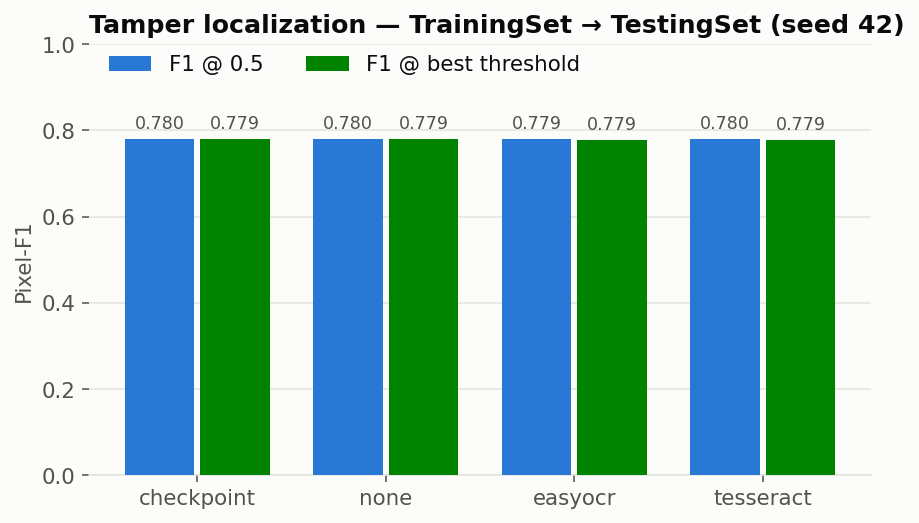

saved /content/drive/MyDrive/HLCV_samira/final_seed42/figures/fig2_threshold_sensitivity.png


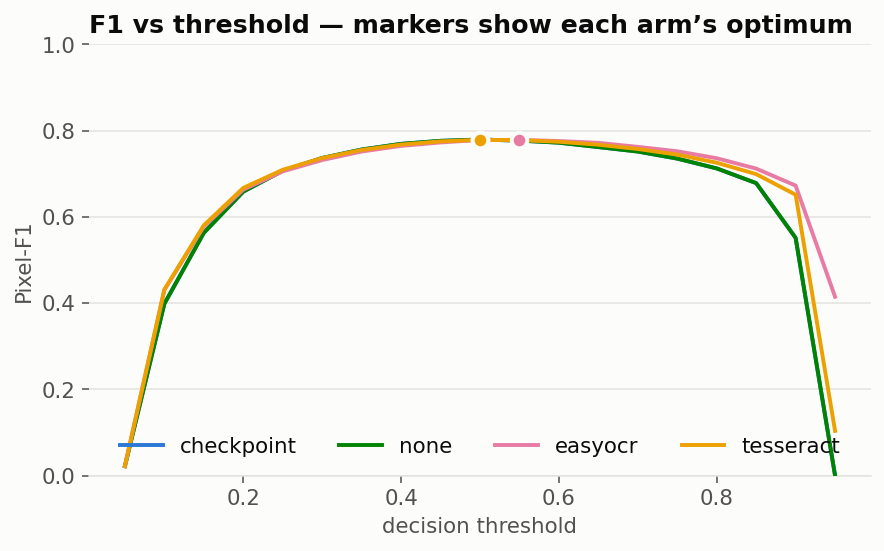

In [26]:
# --- Figure 1: main results (F1 at fixed vs optimal threshold) ---
arms = [a for a in ['checkpoint'] + BACKENDS if a in results]
fig, ax = plt.subplots(figsize=(7.2, 4.0))
bars(ax, arms, ['F1 @ 0.5', 'F1 @ best threshold'],
     [[results[a]['pixel_f1'] for a in arms],
      [results[a]['f1_at_best_threshold'] for a in arms]])
style(ax, 'Pixel-F1')
ax.set_title('Tamper localization — TrainingSet → TestingSet (seed 42)')
save(fig, 'fig1_main_results'); plt.show()

# --- Figure 2: threshold sensitivity (one line per arm) ---
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for i, a in enumerate(arms):
    sw = sweep[a]
    ax.plot(sw['thresholds'], sw['f1s'], color=SERIES[i], linewidth=2, label=a, zorder=3)
    ax.plot([sw['best_threshold']], [sw['f1_best']], 'o', ms=8, color=SERIES[i],
            markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)
style(ax, 'Pixel-F1'); ax.set_xlabel('decision threshold')
ax.legend(loc='lower center', ncol=len(arms))
ax.set_title('F1 vs threshold — markers show each arm’s optimum')
save(fig, 'fig2_threshold_sensitivity'); plt.show()

saved /content/drive/MyDrive/HLCV_samira/final_seed42/figures/fig3_ocr_region_proposal.png


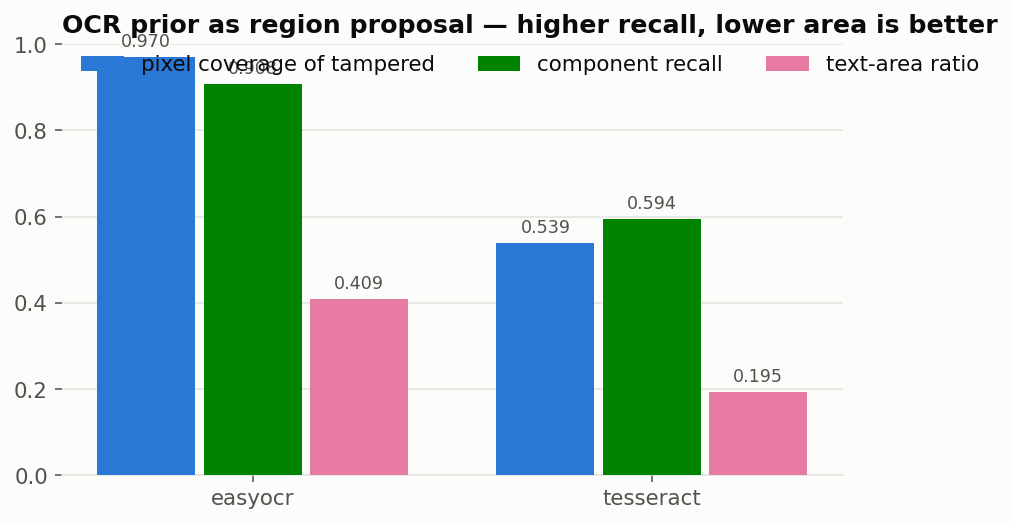

saved /content/drive/MyDrive/HLCV_samira/final_seed42/figures/fig4_ocr_runtime.png


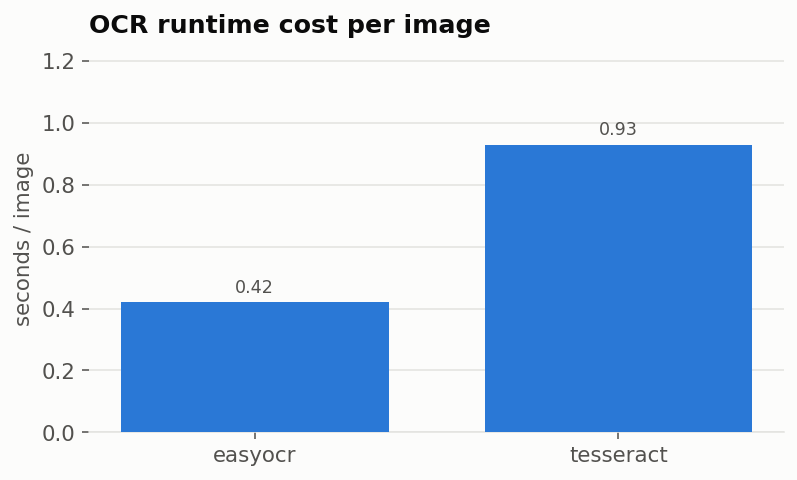

In [27]:
# --- Figure 3: OCR module as a region proposal (recall vs how much area it keeps) ---
bk = [b for b in ['easyocr', 'tesseract'] if b in ocr_stats]
fig, ax = plt.subplots(figsize=(7.2, 4.0))
bars(ax, bk, ['pixel coverage of tampered', 'component recall', 'text-area ratio'],
     [[ocr_stats[b]['pixel_recall_coverage'] for b in bk],
      [ocr_stats[b]['component_recall'] for b in bk],
      [ocr_stats[b]['text_area_ratio'] for b in bk]])
style(ax)
ax.set_title('OCR prior as region proposal — higher recall, lower area is better')
save(fig, 'fig3_ocr_region_proposal'); plt.show()

# --- Figure 4: cost of the OCR module ---
fig, ax = plt.subplots(figsize=(6.4, 3.6))
rt = [ocr_stats[b]['runtime_per_image_sec'] for b in bk]
bars(ax, bk, ['seconds / image'], [rt], ymax=max(rt) * 1.35 if rt else 1, fmt='{:.2f}')
style(ax, 'seconds / image', ymax=max(rt) * 1.35 if rt else 1)
ax.set_title('OCR runtime cost per image')
save(fig, 'fig4_ocr_runtime'); plt.show()

loaded tesseract.pth


/tmp/ipykernel_930/1623635787.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


saved /content/drive/MyDrive/HLCV_samira/final_seed42/figures/fig5_qualitative.png


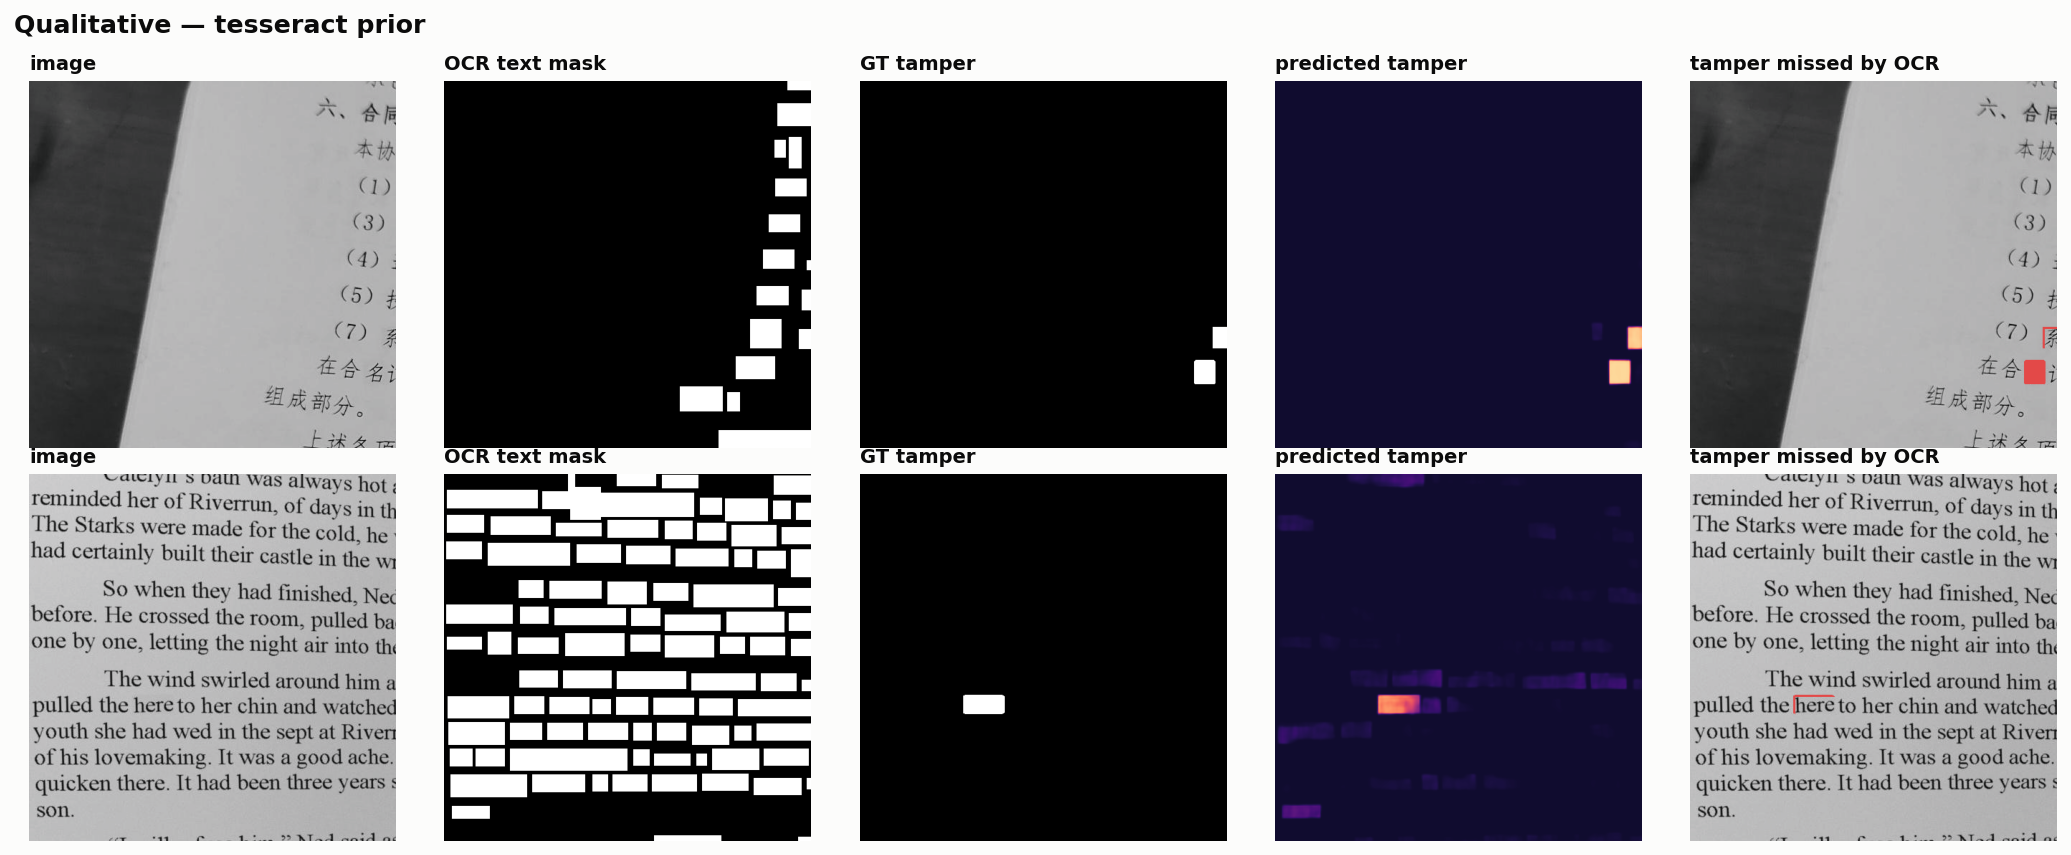

In [28]:
# --- Figure 5: qualitative — image | OCR mask | GT | prediction | missed tampered ---
QUAL_BACKEND = 'tesseract' if 'tesseract' in ocr_stats else 'easyocr'
backend, cache = make_ocr(QUAL_BACKEND)
model = build_model(); wire_prior(model)
saved = OUT / 'arms' / f'{QUAL_BACKEND}.pth'          # written by the arms cell
if saved.exists():
    blob = torch.load(saved, map_location='cpu')
    sd = blob.get('state_dict', blob)
    model.load_state_dict({k.replace('module.', ''): v for k, v in sd.items()}, strict=False)
    print('loaded', saved.name)
model.eval()

batch = next(iter(test_loader))
with torch.no_grad():
    tm = batch_text_masks(batch, backend, cache)
    model.model.segmentation_head.text_mask = tm
    with autocast(enabled=(DEVICE == 'cuda')):
        logits = forward_dtd(model, batch)
        if logits.shape[-2:] != batch['label'].shape[-2:]:
            logits = F.interpolate(logits, size=batch['label'].shape[-2:], mode='bilinear', align_corners=False)
    prob = torch.softmax(logits.float(), 1)[:, 1].cpu().numpy()

n = min(3, len(prob))
fig, axes = plt.subplots(n, 5, figsize=(15, 3.1 * n))
axes = np.atleast_2d(axes)
for i in range(n):
    img = denorm_tensor(batch['image'][i])
    gt = batch['label'][i, 0].numpy() > 0
    txt = tm[i, 0].cpu().numpy() > 0
    missed = gt & ~txt
    panels = [(img, 'image', None), (txt, 'OCR text mask', 'gray'), (gt, 'GT tamper', 'gray'),
              (prob[i], 'predicted tamper', 'magma')]
    for j, (im, t, cm) in enumerate(panels):
        axes[i, j].imshow(im, cmap=cm, vmin=0 if cm else None, vmax=1 if cm else None)
        axes[i, j].set_title(t, fontsize=10, loc='left'); axes[i, j].axis('off')
    ov = img.copy(); ov[missed] = np.array([227, 73, 72], dtype=np.uint8)   # unrecoverable misses
    axes[i, 4].imshow(ov); axes[i, 4].set_title('tamper missed by OCR', fontsize=10, loc='left')
    axes[i, 4].axis('off')
fig.suptitle(f'Qualitative — {QUAL_BACKEND} prior', x=0.01, ha='left', fontsize=13, weight='semibold')
fig.tight_layout()
save(fig, 'fig5_qualitative'); plt.show()
del model; torch.cuda.empty_cache()

In [29]:
# --- Summary of everything written to Drive ---
print('OUTPUT ROOT:', OUT)
for p in sorted(OUT.rglob('*')):
    if p.is_file() and p.suffix in {'.csv', '.md', '.json', '.png', '.svg', '.pth'}:
        print(f'  {p.relative_to(OUT)}  ({p.stat().st_size/1024:.0f} KB)')

OUTPUT ROOT: /content/drive/MyDrive/HLCV_samira/final_seed42
  arms/easyocr.pth  (263588 KB)
  arms/tesseract.pth  (263590 KB)
  figures/fig1_main_results.png  (63 KB)
  figures/fig1_main_results.svg  (45 KB)
  figures/fig2_threshold_sensitivity.png  (96 KB)
  figures/fig2_threshold_sensitivity.svg  (41 KB)
  figures/fig3_ocr_region_proposal.png  (77 KB)
  figures/fig3_ocr_region_proposal.svg  (44 KB)
  figures/fig4_ocr_runtime.png  (46 KB)
  figures/fig4_ocr_runtime.svg  (32 KB)
  figures/fig5_qualitative.png  (849 KB)
  figures/fig5_qualitative.svg  (1791 KB)
  final_results.csv  (1 KB)
  final_results.md  (1 KB)
  ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_000000016.json  (6 KB)
  ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_000000080.json  (5 KB)
  ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_000000156.json  (4 KB)
  ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_000000180.json  (4 KB)
  ocr_cache/easyocr_cab25afc609b/DocTamperV1-TestingSet_00000

In [31]:
# --- Loss ablation: CE vs +Dice vs +Boundary (FCD, full fine-tune) ---------------------------
# WHY FCD and not TestingSet: the frozen-backbone experiment above cannot test the loss (only
# 42k params train), and on TrainingSet->TestingSet full fine-tuning degrades the checkpoint
# (0.78 -> 0.58) because it was already trained on that data. FCD is the one split the released
# checkpoint never saw, so fine-tuning genuinely helps there and the loss choice can show an
# effect. This is a SECONDARY in-distribution study -- report it separately from the main result.
import subprocess
from src.doctamper_lmdb import get_lmdb_num_samples

FCD_SOURCE = 'DocTamperV1-FCD'
FCD_MAN = Path(CONFIG['MANIFEST_DIR']).parent / 'fcd_lossablation_seed42'
LOSS_STEPS = 400
LOSS_LR = 1e-4

# 1) Extract FCD from the cached zip (all splits are in it).
if not (DATA_ROOT / FCD_SOURCE / 'data.mdb').exists():
    zp = Path('/content/doctamper_kaggle/doctamper.zip')
    if not zp.exists():
        zp = Path(CONFIG['DRIVE_ZIP'])
    print('extracting', FCD_SOURCE, 'from', zp)
    subprocess.run(['unzip', '-o', '-q', str(zp), f'{FCD_SOURCE}/*', '-d', str(DATA_ROOT)], check=True)
assert (DATA_ROOT / FCD_SOURCE / 'data.mdb').exists(), 'FCD extraction failed'

# 2) Size the splits from FCD's ACTUAL length (it is a test split, so it is small; the
#    generator hard-fails if train+val+test exceeds it).
n_fcd = get_lmdb_num_samples(DATA_ROOT / FCD_SOURCE)
test_n = max(50, min(400, n_fcd // 5))
val_n = max(25, min(200, n_fcd // 10))
train_n = n_fcd - test_n - val_n
assert train_n > 0, f'FCD too small: {n_fcd}'
print(f'FCD has {n_fcd} samples -> train {train_n} / val {val_n} / test {test_n}')

if not (FCD_MAN / 'test.json').exists():
    cmd = [sys.executable, f"{CONFIG['PROJECT_DIR']}/scripts/generate_doctamper_subset.py",
           '--data-root', str(DATA_ROOT), '--output-dir', str(FCD_MAN), '--seed', str(CONFIG['SEED']),
           '--train-source', FCD_SOURCE, '--test-source', FCD_SOURCE,
           '--train-size', str(train_n), '--val-size', str(val_n), '--test-size', str(test_n),
           '--allow-eval-source-for-training']
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stdout)
    if r.returncode != 0:                      # surface the real error instead of swallowing it
        raise RuntimeError(f'manifest generation failed:\n{r.stderr}')
for s in ['train', 'val', 'test']:
    assert (FCD_MAN / f'{s}.json').exists(), f'FCD manifest missing: {s}'

def fcd_loader(split, shuffle):
    ds = ManifestDocTamperDataset(DATA_ROOT, FCD_MAN / f'{split}.json', 'qt_table.pk', CONFIG['JPEG_QUALITY'])
    return DataLoader(ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=shuffle,
                      num_workers=0, drop_last=shuffle)
fcd_train, fcd_test = fcd_loader('train', True), fcd_loader('test', False)
print(f'FCD loaders: train {len(fcd_train.dataset)} | test {len(fcd_test.dataset)}')

# 3) Reference point: the released checkpoint on FCD, no training.
loss_results = {}
m = build_model()
loss_results['checkpoint (no train)'], _, _ = evaluate(m, fcd_test)
print('checkpoint:', {k: round(v, 4) for k, v in loss_results['checkpoint (no train)'].items()})
del m; torch.cuda.empty_cache()

# 4) One full fine-tune per loss configuration (identical data, seed, steps).
LOSS_CONFIGS = {'CE only': (0.0, 0.0), 'CE+Dice': (1.0, 0.0), 'CE+Dice+Boundary': (1.0, 0.5)}
for label, (ld, lb) in LOSS_CONFIGS.items():
    print(f'=== loss: {label} (lambda_dice={ld}, lambda_bound={lb}) ===')
    crit = CombinedTamperLoss(lambda_dice=ld, lambda_bound=lb)
    model = build_model()
    opt = torch.optim.AdamW(model.parameters(), lr=LOSS_LR, weight_decay=CONFIG['WEIGHT_DECAY'])
    scaler = GradScaler(); model.train(); it = iter(fcd_train)
    for step in range(LOSS_STEPS):
        try: batch = next(it)
        except StopIteration: it = iter(fcd_train); batch = next(it)
        target = batch['label'].squeeze(1).long().to(DEVICE)
        opt.zero_grad(set_to_none=True)
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = forward_dtd(model, batch)
            if logits.shape[-2:] != target.shape[-2:]:
                logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
            loss, parts = crit(logits, target)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        if step % 100 == 0:
            print(f"   step {step:04d}/{LOSS_STEPS} total={float(parts['total']):.4f}")
    met, _, _ = evaluate(model, fcd_test)
    loss_results[label] = met
    print(' TEST:', {k: round(v, 4) for k, v in met.items()})
    del model; torch.cuda.empty_cache()

# 5) Table (saved next to the main results).
lines = [f'# Loss ablation (FCD, full fine-tune, seed 42, {LOSS_STEPS} steps)', '',
         f'FCD split: train {train_n} / val {val_n} / test {test_n}', '',
         '| loss | pixel_f1 | precision | recall | iou | auc |', '|---|---|---|---|---|---|']
print(f'\n{"loss":<22}{"F1":>9}{"precision":>11}{"recall":>9}{"IoU":>9}{"AUC":>9}')
for k, v in loss_results.items():
    print(f'{k:<22}{v["pixel_f1"]:>9.4f}{v["precision"]:>11.4f}{v["recall"]:>9.4f}{v["iou"]:>9.4f}{v["auc"]:>9.4f}')
    lines.append(f'| {k} | ' + ' | '.join(f'{v[c]:.4f}' for c in ['pixel_f1','precision','recall','iou','auc']) + ' |')
(OUT / 'loss_ablation.md').write_text('\n'.join(lines) + '\n')
print('\nsaved ->', OUT / 'loss_ablation.md')
print('NOTE: run-to-run noise is ~+/-0.005 F1; smaller differences are not meaningful.')

FCD has 2000 samples -> train 1400 / val 200 / test 400
Wrote manifests to /content/drive/MyDrive/HLCV_samira/manifests/fcd_lossablation_seed42
{'seed': 42, 'data_root': '/content/doctamper_train_test', 'train_source': 'DocTamperV1-FCD', 'test_source': 'DocTamperV1-FCD', 'manifests': {'train': 'train.json', 'val': 'val.json', 'test': 'test.json'}, 'sizes': {'train': 1400, 'val': 200, 'test': 400}, 'note': 'Original LMDB files are unchanged. Manifests select deterministic sample IDs.'}

FCD loaders: train 1400 | test 400


/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


checkpoint: {'pixel_f1': 0.5302, 'precision': 0.7782, 'recall': 0.4021, 'iou': 0.3607, 'auc': 0.934}
=== loss: CE only (lambda_dice=0.0, lambda_bound=0.0) ===


/tmp/ipykernel_930/1294511565.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); model.train(); it = iter(fcd_train)
/tmp/ipykernel_930/1294511565.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


   step 0000/400 total=0.1709
   step 0100/400 total=0.0334
   step 0200/400 total=0.0184
   step 0300/400 total=0.0152


...

 TEST: {'pixel_f1': 0.8679, 'precision': 0.9589, 'recall': 0.7927, 'iou': 0.7667, 'auc': 0.9845}
=== loss: CE+Dice+Boundary (lambda_dice=1.0, lambda_bound=0.5) ===


/tmp/ipykernel_930/1294511565.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(); model.train(); it = iter(fcd_train)
/tmp/ipykernel_930/1294511565.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


   step 0000/400 total=1.5630
   step 0100/400 total=1.0379
   step 0200/400 total=0.2347
   step 0300/400 total=0.1686


/tmp/ipykernel_930/1392918702.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


 TEST: {'pixel_f1': 0.8874, 'precision': 0.947, 'recall': 0.8349, 'iou': 0.7977, 'auc': 0.9855}

loss                         F1  precision   recall      IoU      AUC
checkpoint (no train)    0.5302     0.7782   0.4021   0.3607   0.9340
CE only                  0.8878     0.9343   0.8457   0.7982   0.9930
CE+Dice                  0.8679     0.9589   0.7927   0.7667   0.9845
CE+Dice+Boundary         0.8874     0.9470   0.8349   0.7977   0.9855

saved -> /content/drive/MyDrive/HLCV_samira/final_seed42/loss_ablation.md
NOTE: run-to-run noise is ~+/-0.005 F1; smaller differences are not meaningful.
